<a href="https://colab.research.google.com/github/pstrings/MachineLearningTraining/blob/main/Global_Pollution_Regression_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing the required dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Importing the dataset

In [2]:
pollution_df = pd.read_csv("https://drive.google.com/uc?export=download&id=1AEMcCWzJ24fc26Q761SEOa1sOsZiJBC5")

# First analysis of data

In [3]:
pollution_df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


- From the data above we can see that the numerical values are wildly different in scale so we will have to bring them to standard scale by calculating the z-score making their mean 0 and standard deviation 1.

In [4]:
pollution_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Country                                 200 non-null    object 
 1   Year                                    200 non-null    int64  
 2   Air_Pollution_Index                     200 non-null    float64
 3   Water_Pollution_Index                   200 non-null    float64
 4   Soil_Pollution_Index                    200 non-null    float64
 5   Industrial_Waste (in tons)              200 non-null    float64
 6   Energy_Recovered (in GWh)               200 non-null    float64
 7   CO2_Emissions (in MT)                   200 non-null    float64
 8   Renewable_Energy (%)                    200 non-null    float64
 9   Plastic_Waste_Produced (in tons)        200 non-null    float64
 10  Energy_Consumption_Per_Capita (in MWh)  200 non-null    float6

- Except for country all other fields are number so we only need to one hot encode country.

In [5]:
pollution_df['Year'].value_counts().sort_index(ascending=True)

,count
Year,
2000,10
2001,9
2002,13
2003,10
2004,11
2005,15
2006,6
2007,11
2008,7


- I'll amend my previous assumption, Year will also be a categorical data ranging from 2000 to 2019 which is ordered so we can use Ordinal Encoding on this.

In [6]:
pollution_df.describe()

,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
count,200.000000,200.00000,200.000000,200.000000,200.00000,200.000000,200.000000,200.000000,200.000000,200.00000,200.000000,200.000000
mean,2009.335000,180.62695,115.068100,76.488550,52891.68150,260.448700,24.878100,27.799700,24492.893550,9.43575,104.271300,35307.602400
std,5.765325,67.07331,47.580911,39.692727,27224.49169,147.141923,14.470892,12.361879,14421.356002,5.57567,56.906574,19481.714455
min,2000.000000,50.30000,31.130000,11.150000,1019.37000,11.730000,1.920000,5.040000,542.950000,0.53000,2.320000,1298.700000
25%,2004.000000,134.97250,74.550000,40.895000,31201.97250,118.355000,11.220000,17.700000,12843.882500,4.58250,60.960000,19525.020000
50%,2010.000000,183.38500,112.305000,78.600000,55299.15000,273.140000,25.355000,29.170000,24121.540000,9.22500,104.965000,35043.325000
75%,2014.000000,237.42500,157.477500,109.212500,74805.82500,384.957500,38.550000,37.072500,36516.232500,13.99750,150.930000,51629.547500
max,2019.000000,297.95000,199.320000,149.230000,99739.36000,499.980000,49.690000,49.560000,49852.280000,19.98000,198.820000,69143.140000


- We can see the mean, count, standard deviation, minimum, maximum, and (25, 50, and 70)th percentile.

In [7]:
pollution_df.isna().sum()

,0
Country,0
Year,0
Air_Pollution_Index,0
Water_Pollution_Index,0
Soil_Pollution_Index,0
Industrial_Waste (in tons),0
Energy_Recovered (in GWh),0
CO2_Emissions (in MT),0
Renewable_Energy (%),0
Plastic_Waste_Produced (in tons),0


- So with this we know there is no null values so there is no need for imputation in the dataset.

In [8]:
pollution_df.corr(numeric_only=True)

,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
Year,1.000000,0.008147,0.007790,0.052949,-0.064372,0.088332,0.002163,0.079472,-0.108469,-0.073536,0.144039,-0.141585
Air_Pollution_Index,0.008147,1.000000,-0.022540,0.036020,0.033252,0.002997,-0.038179,0.011301,-0.018517,-0.053284,-0.028884,-0.069371
Water_Pollution_Index,0.007790,-0.022540,1.000000,-0.020505,0.126092,-0.041828,-0.002979,-0.056183,0.044215,-0.001960,0.239446,-0.019975
Soil_Pollution_Index,0.052949,0.036020,-0.020505,1.000000,0.026609,0.064076,0.041913,-0.077602,0.129932,-0.023043,-0.100273,0.115521
Industrial_Waste (in tons),-0.064372,0.033252,0.126092,0.026609,1.000000,-0.161309,-0.060737,-0.149251,0.066844,0.017323,-0.030398,0.061563
Energy_Recovered (in GWh),0.088332,0.002997,-0.041828,0.064076,-0.161309,1.000000,0.024758,0.043533,-0.072946,-0.030284,-0.075100,0.004535
CO2_Emissions (in MT),0.002163,-0.038179,-0.002979,0.041913,-0.060737,0.024758,1.000000,-0.038888,0.065154,-0.011750,0.020784,0.029267
Renewable_Energy (%),0.079472,0.011301,-0.056183,-0.077602,-0.149251,0.043533,-0.038888,1.000000,-0.125175,0.040398,-0.008378,-0.221096
Plastic_Waste_Produced (in tons),-0.108469,-0.018517,0.044215,0.129932,0.066844,-0.072946,0.065154,-0.125175,1.000000,-0.021884,-0.029782,0.090283
Energy_Consumption_Per_Capita (in MWh),-0.073536,-0.053284,-0.001960,-0.023043,0.017323,-0.030284,-0.011750,0.040398,-0.021884,1.000000,0.040493,0.137791


- From this we can already see that Energy Recovered doesn't have much linear correlation with any of the other columns.

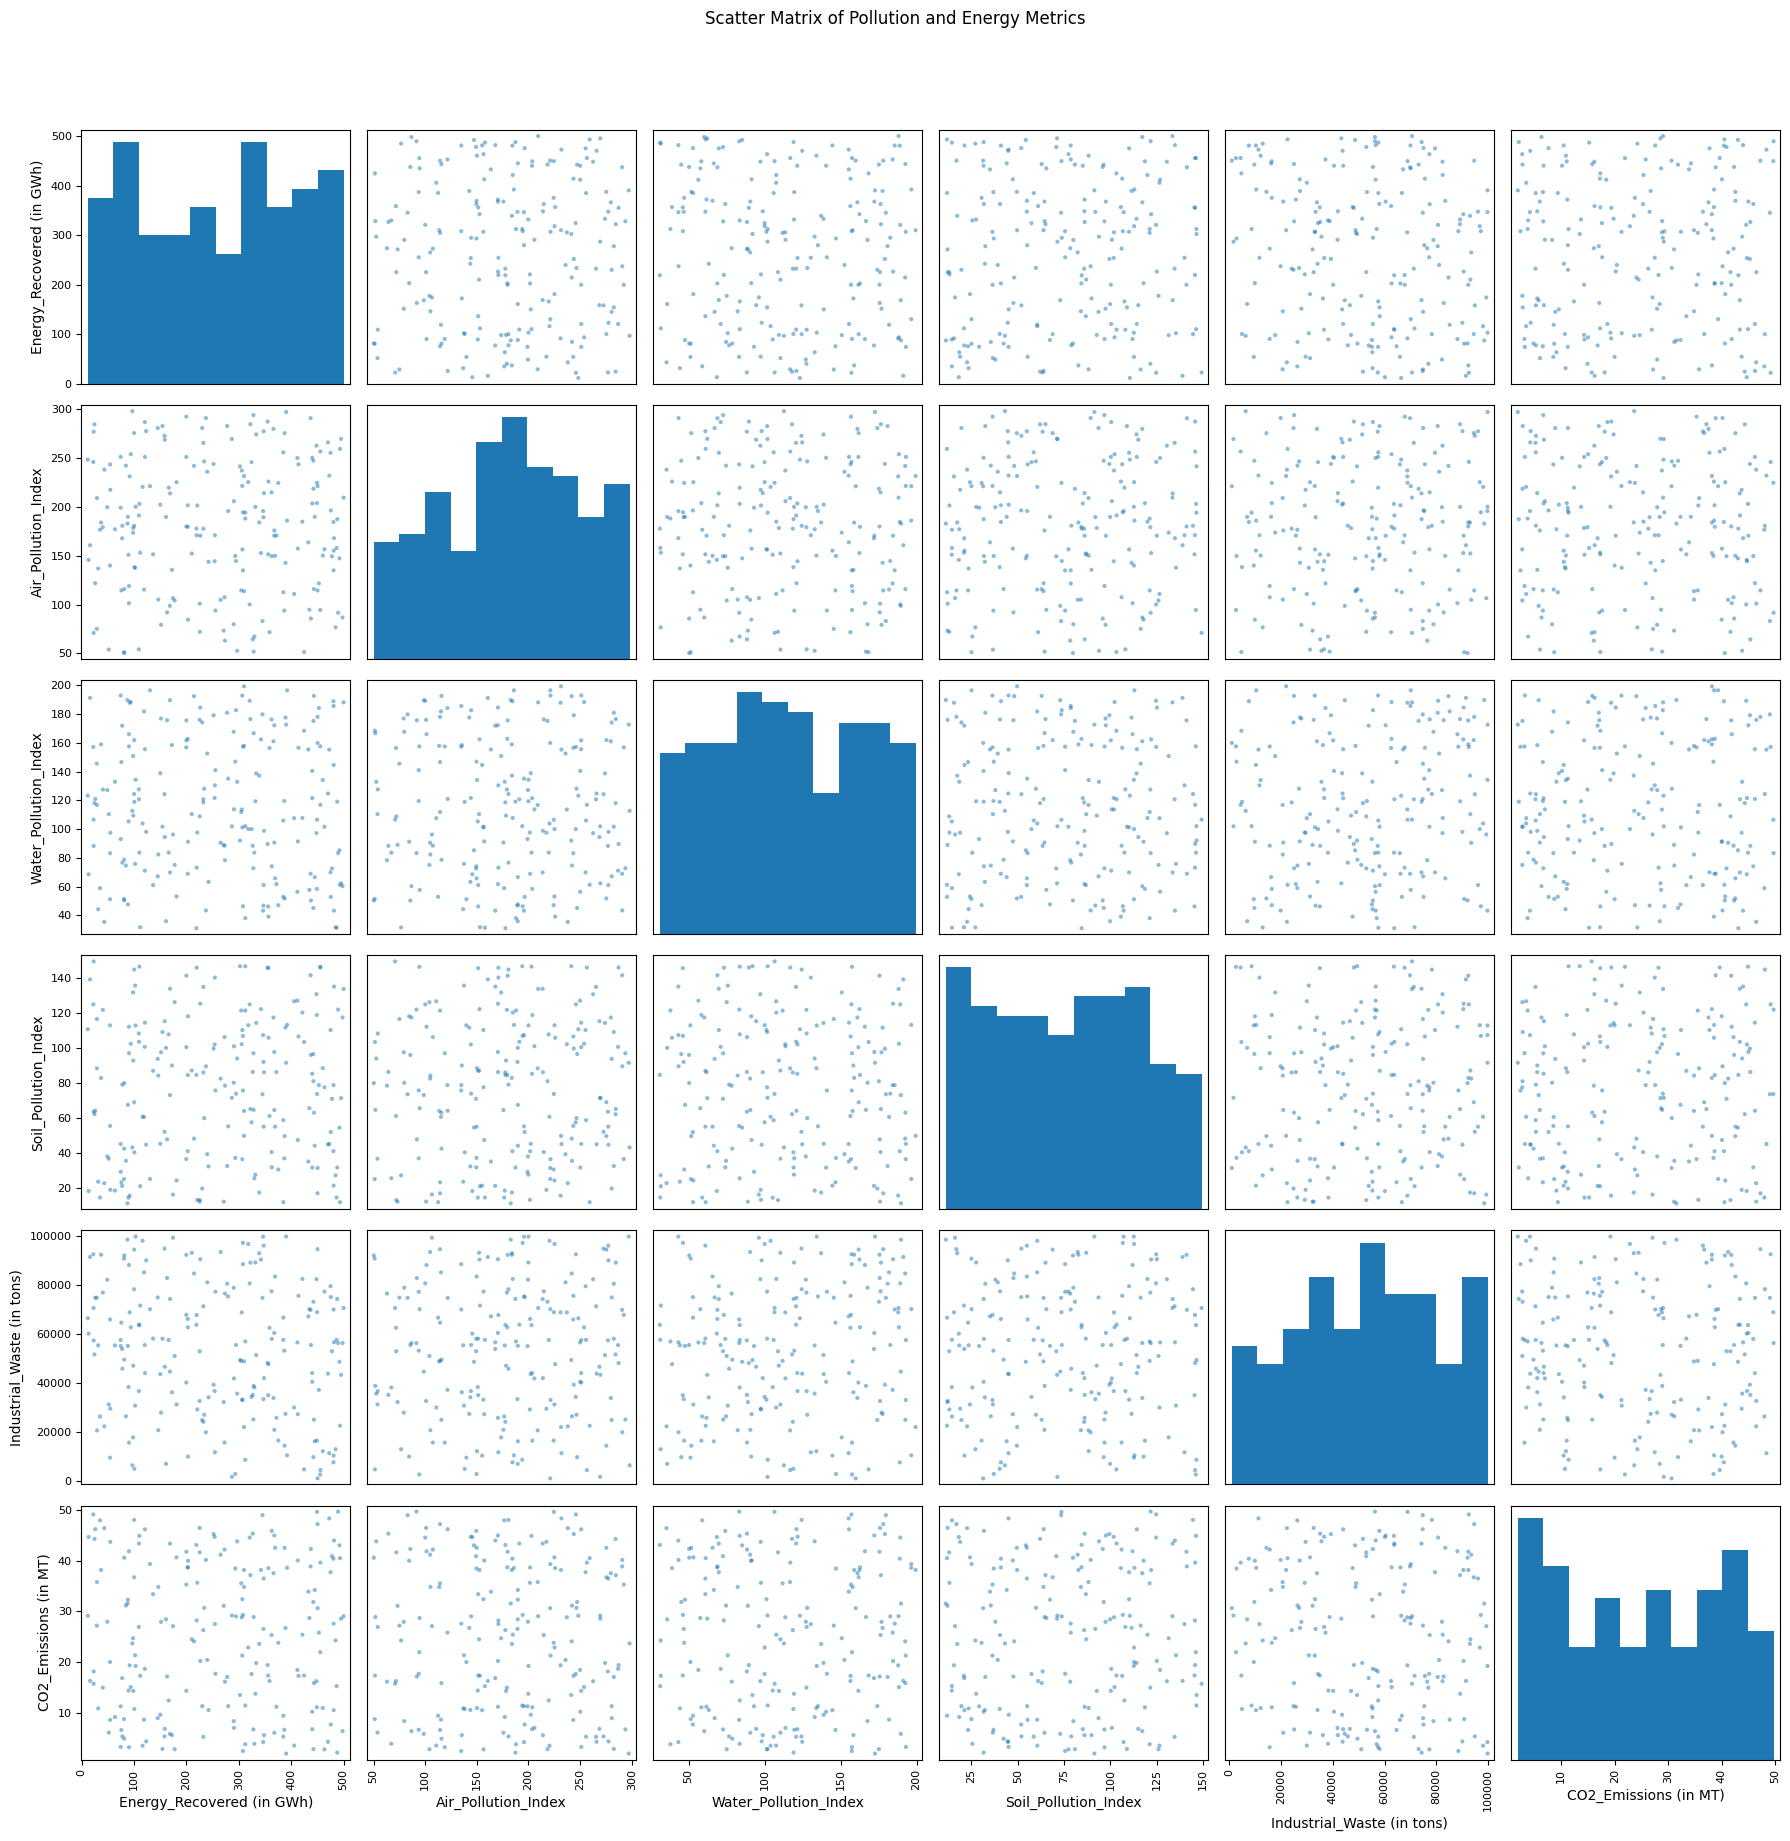

In [9]:
scatter_df = pollution_df[['Energy_Recovered (in GWh)' ,'Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index', 'Industrial_Waste (in tons)', 'CO2_Emissions (in MT)']]

pd.plotting.scatter_matrix(scatter_df, figsize=(18, 18))
plt.suptitle('Scatter Matrix of Pollution and Energy Metrics', y=1.02) # Add a main title for clarity
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent title overlap and improve spacing
plt.show()

- The plot again reinforces the idea that energy recovered doesn't have a clear linear relationship with these other columns

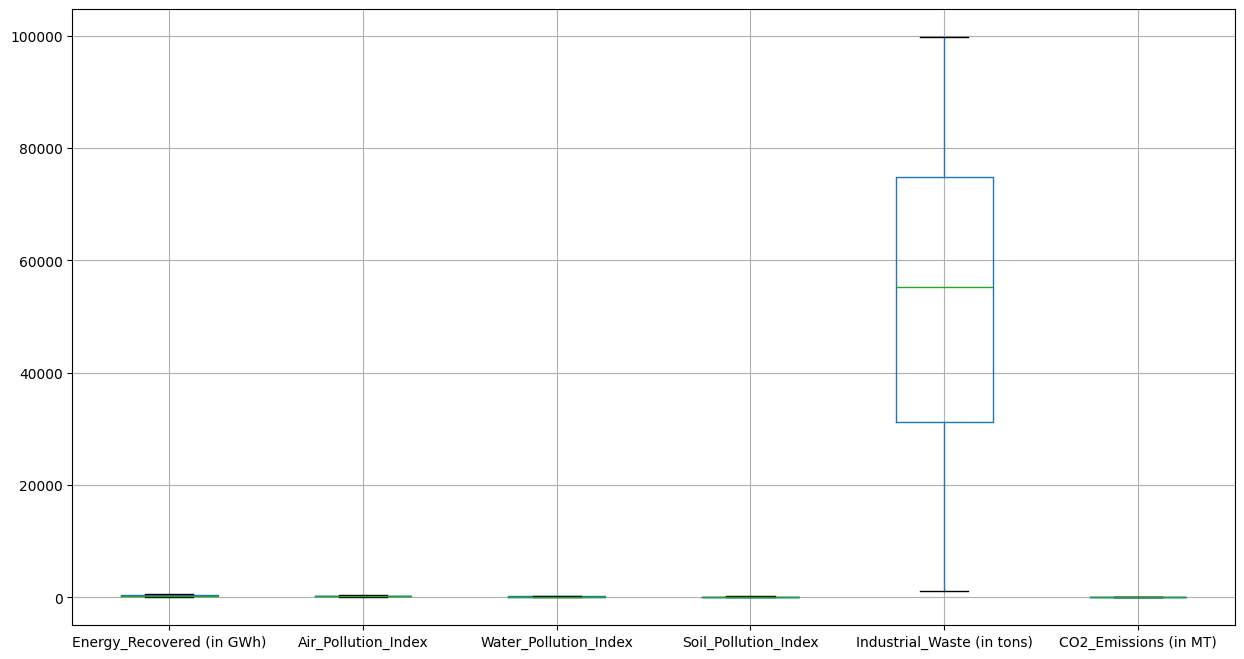

In [10]:
pd.plotting.boxplot_frame(scatter_df, figsize=(15, 8))
plt.show()

- The scale of industrial waste is really high making the other values dwarf in comparision

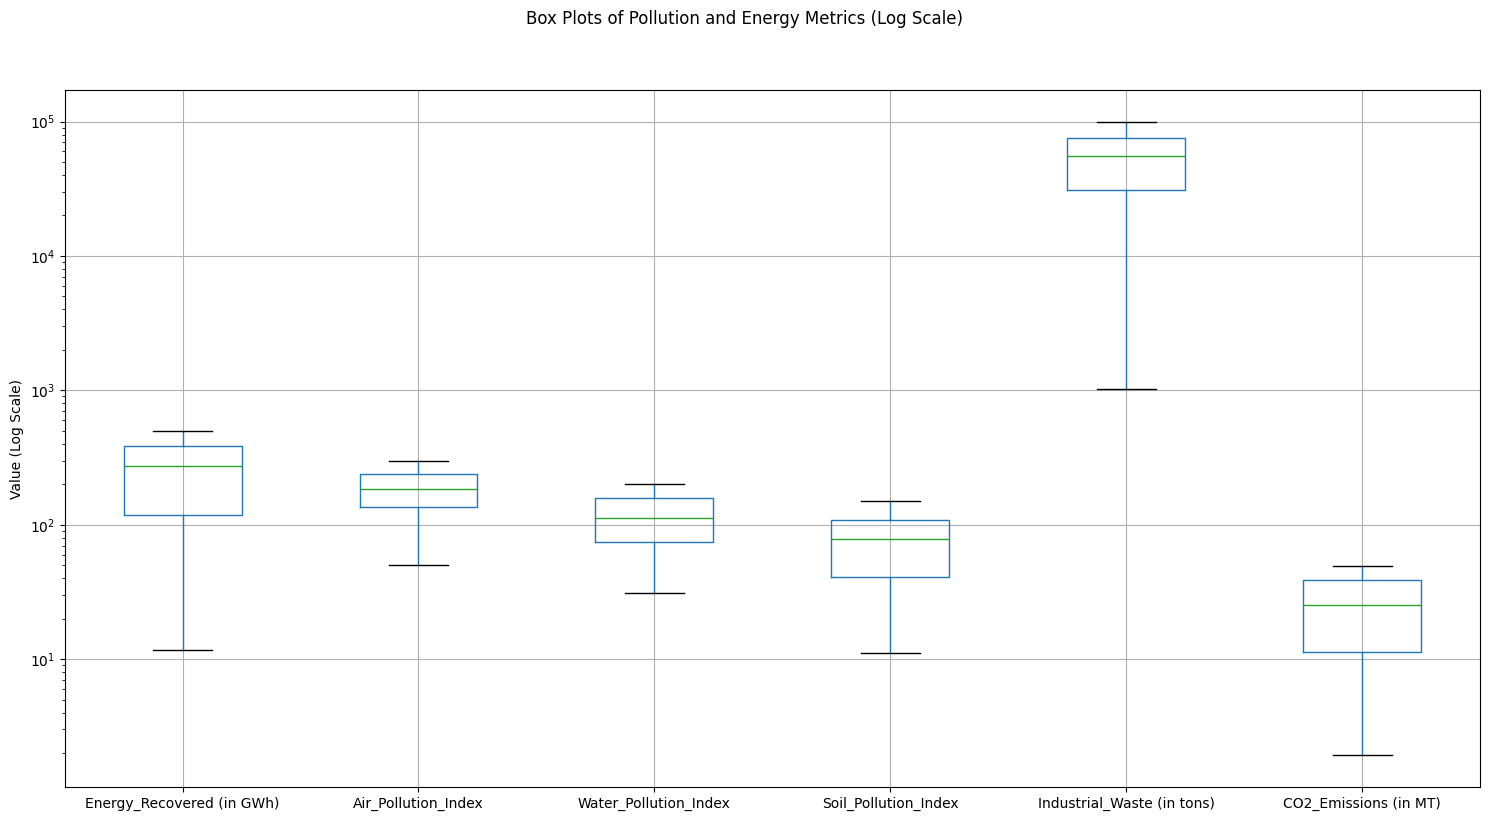

In [11]:
ax = pd.plotting.boxplot_frame(scatter_df, figsize=(15, 8))

# Set y-axis to log scale for the single Axes object
ax.set_yscale('log')
ax.set_ylabel('Value (Log Scale)')

# Access the figure from the axes object to set suptitle and tight_layout
fig = ax.figure
fig.suptitle('Box Plots of Pollution and Energy Metrics (Log Scale)', y=1.02)
fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

Here we can see that Industrial Waste is on a much larger scale but IQR something like C02 emission or Energy Recovered is larger. There are no obvious looking outliers. We can also see a left skey in the data here, median is much closer to Q3.

# Getting Data Ready

- Since there are no missing values. I'll move to scalling the data.

In [12]:
yearly_trends = pollution_df.groupby('Year').mean(numeric_only=True)
yearly_trends

,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
Year,,,,,,,,,,,
2000,197.796000,118.513000,69.283000,40942.043000,296.889000,27.732000,20.813000,31524.544000,11.969000,120.280000,41918.539000
2001,137.964444,83.933333,71.340000,53411.355556,288.877778,18.300000,24.892222,27631.664444,9.268889,103.955556,41467.384444
2002,174.661538,123.617692,75.344615,47335.282308,259.750769,26.866923,27.226923,27279.453846,9.295385,67.831538,40617.903846
2003,203.103000,133.080000,100.687000,67112.575000,208.139000,28.270000,27.470000,25589.985000,12.074000,77.348000,33669.050000
2004,171.120909,120.719091,69.959091,43974.889091,186.458182,18.640909,31.131818,23035.718182,8.210000,102.971818,35126.090909
2005,179.756000,108.245333,72.922000,62598.769333,240.748667,25.335333,25.506000,25350.681333,10.126667,80.126667,38479.712667
2006,197.326667,115.016667,100.613333,54126.826667,197.411667,28.221667,28.836667,33777.623333,5.738333,103.866667,42428.975000
2007,174.349091,107.464545,55.718182,71923.467273,242.578182,23.131818,27.225455,18133.515455,8.701818,129.476364,36197.763636
2008,194.782857,102.114286,75.508571,58171.600000,289.600000,28.960000,31.997143,19682.964286,10.480000,104.714286,32567.644286


- 'Energy Consumption per Capita' is already present in dataset

### Visualizations

#### Yearly Trends in Pollution Indices

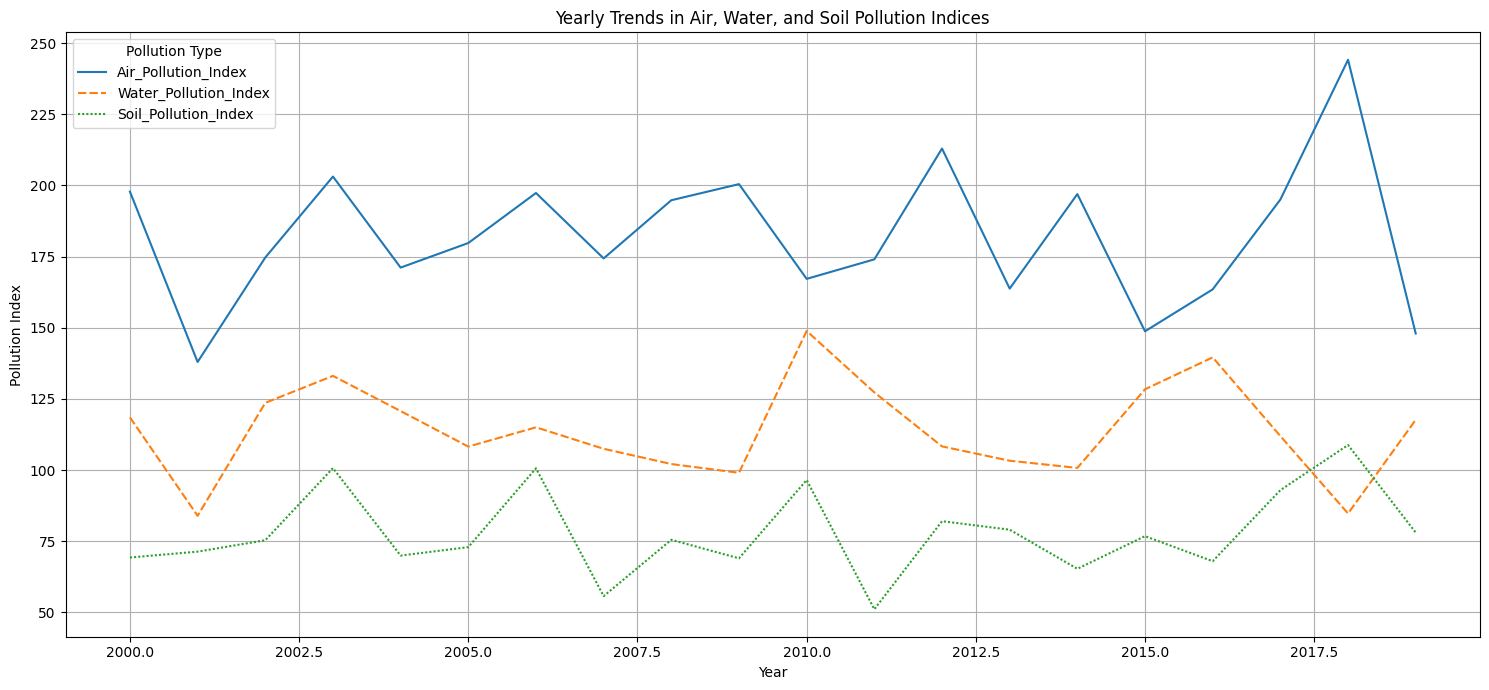

In [13]:
plt.figure(figsize=(15, 7))
sns.lineplot(data=yearly_trends[['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']])
plt.title('Yearly Trends in Air, Water, and Soil Pollution Indices')
plt.xlabel('Year')
plt.ylabel('Pollution Index')
plt.grid(True)
plt.legend(title='Pollution Type')
plt.tight_layout()
plt.show()

#### Pollution Levels Across Countries (Box Plots)

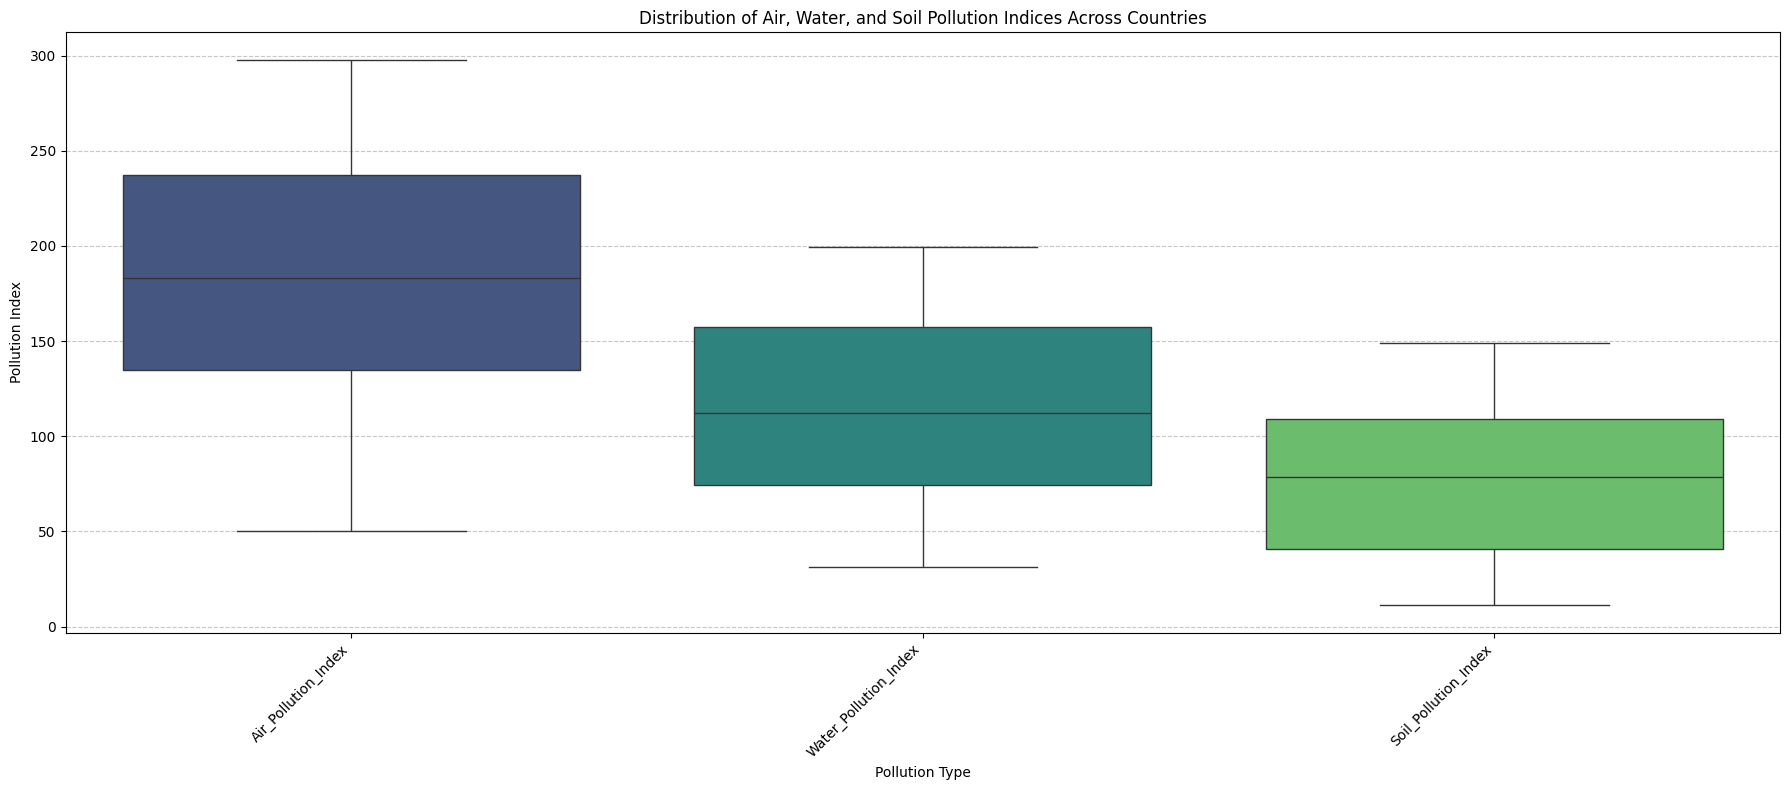

In [14]:
pollution_melted = pollution_df.melt(id_vars=['Country'],
                                       value_vars=['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index'],
                                       var_name='Pollution_Type',
                                       value_name='Pollution_Index')

plt.figure(figsize=(18, 8))
sns.boxplot(x='Pollution_Type', y='Pollution_Index', data=pollution_melted, hue='Pollution_Type', palette='viridis', legend=False)
plt.title('Distribution of Air, Water, and Soil Pollution Indices Across Countries')
plt.xlabel('Pollution Type')
plt.ylabel('Pollution Index')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Top/Bottom Countries by Average Pollution Index

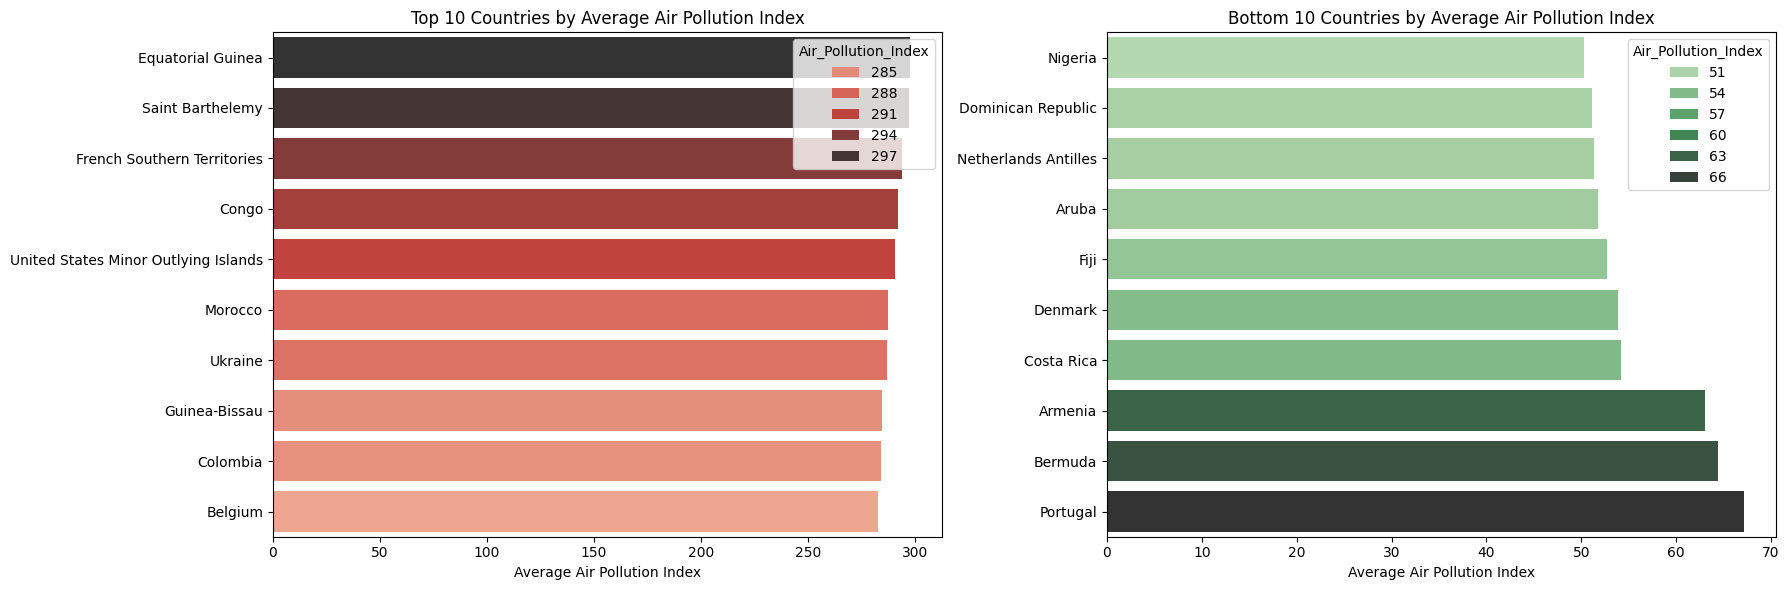

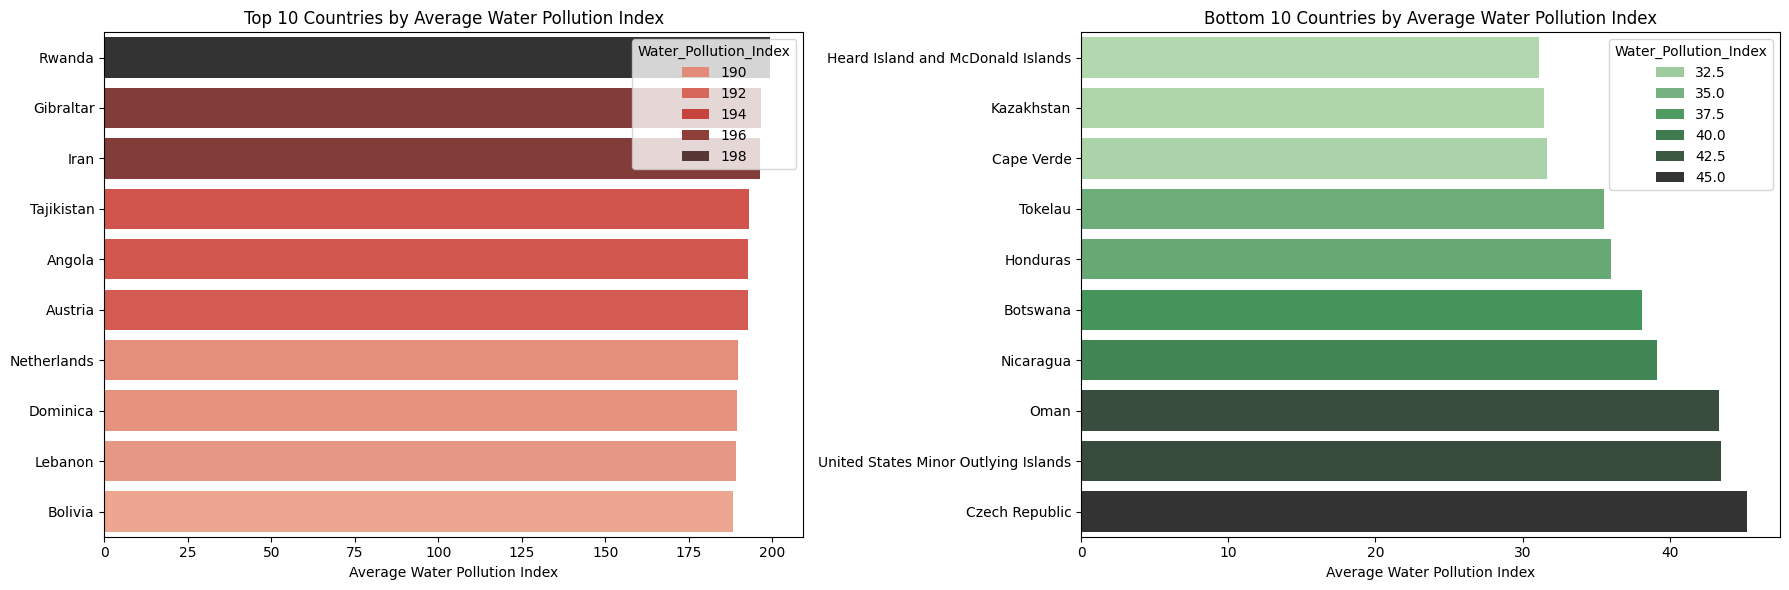

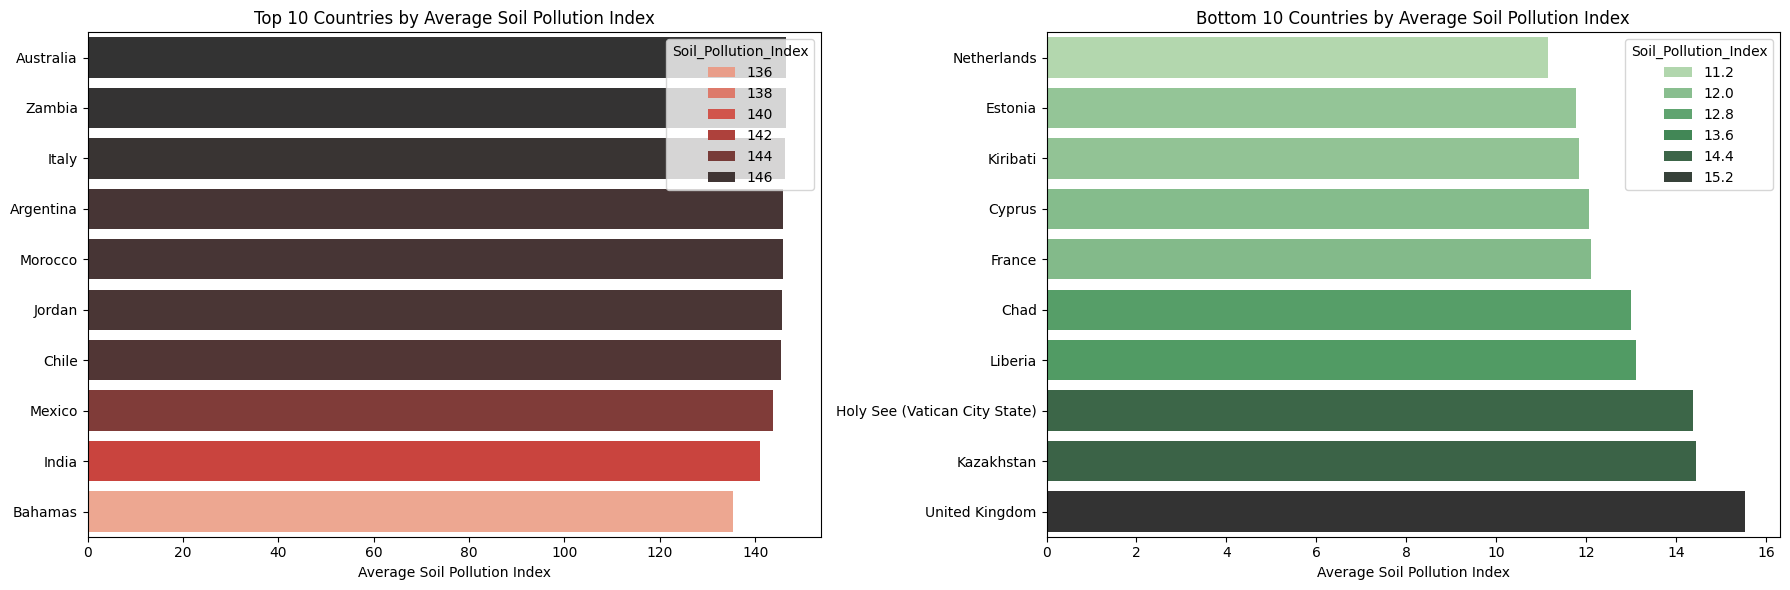

In [15]:
avg_pollution_by_country = pollution_df.groupby('Country')[['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']].mean().reset_index()

# Sort and select top/bottom N countries for visualization
top_air = avg_pollution_by_country.nlargest(10, 'Air_Pollution_Index')
bottom_air = avg_pollution_by_country.nsmallest(10, 'Air_Pollution_Index')

top_water = avg_pollution_by_country.nlargest(10, 'Water_Pollution_Index')
bottom_water = avg_pollution_by_country.nsmallest(10, 'Water_Pollution_Index')

top_soil = avg_pollution_by_country.nlargest(10, 'Soil_Pollution_Index')
bottom_soil = avg_pollution_by_country.nsmallest(10, 'Soil_Pollution_Index')

# Plotting for Air Pollution
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(x='Air_Pollution_Index', y='Country', data=top_air, ax=axes[0], palette='Reds_d', hue='Air_Pollution_Index')
axes[0].set_title('Top 10 Countries by Average Air Pollution Index')
axes[0].set_xlabel('Average Air Pollution Index')
axes[0].set_ylabel('')

sns.barplot(x='Air_Pollution_Index', y='Country', data=bottom_air, ax=axes[1], palette='Greens_d', hue='Air_Pollution_Index')
axes[1].set_title('Bottom 10 Countries by Average Air Pollution Index')
axes[1].set_xlabel('Average Air Pollution Index')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# Plotting for Water Pollution
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(x='Water_Pollution_Index', y='Country', data=top_water, ax=axes[0], palette='Reds_d', hue='Water_Pollution_Index')
axes[0].set_title('Top 10 Countries by Average Water Pollution Index')
axes[0].set_xlabel('Average Water Pollution Index')
axes[0].set_ylabel('')

sns.barplot(x='Water_Pollution_Index', y='Country', data=bottom_water, ax=axes[1], palette='Greens_d', hue='Water_Pollution_Index')
axes[1].set_title('Bottom 10 Countries by Average Water Pollution Index')
axes[1].set_xlabel('Average Water Pollution Index')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# Plotting for Soil Pollution
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(x='Soil_Pollution_Index', y='Country', data=top_soil, ax=axes[0], palette='Reds_d', hue='Soil_Pollution_Index')
axes[0].set_title('Top 10 Countries by Average Soil Pollution Index')
axes[0].set_xlabel('Average Soil Pollution Index')
axes[0].set_ylabel('')

sns.barplot(x='Soil_Pollution_Index', y='Country', data=bottom_soil, ax=axes[1], palette='Greens_d', hue='Soil_Pollution_Index')
axes[1].set_title('Bottom 10 Countries by Average Soil Pollution Index')
axes[1].set_xlabel('Average Soil Pollution Index')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [16]:
X = pollution_df.drop("Energy_Recovered (in GWh)", axis=1)
y = pollution_df['Energy_Recovered (in GWh)']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
categorical = ['Country']
ordinal_category = ['Year']
numerical_data = ['Air_Pollution_Index', 'Water_Pollution_Index',
       'Soil_Pollution_Index', 'Industrial_Waste (in tons)', 'CO2_Emissions (in MT)',
       'Renewable_Energy (%)', 'Plastic_Waste_Produced (in tons)',
       'Energy_Consumption_Per_Capita (in MWh)', 'Population (in millions)',
       'GDP_Per_Capita (in USD)']
ordinal_categories = np.arange(2000, 2020, 1)

In [19]:
numerical_pipeline = make_pipeline(StandardScaler())
categorical_pipeline = make_pipeline(OneHotEncoder(handle_unknown='ignore'))
ordinal_pipeline = make_pipeline(OrdinalEncoder(categories=[ordinal_categories]))

In [20]:
data_transformer = ColumnTransformer(
    [
      ('numerical', numerical_pipeline, numerical_data),
      ('categorical', categorical_pipeline, categorical),
      ('ordinal', ordinal_pipeline, ordinal_category)
    ]
)

- Now I will fit and transform the data

In [21]:
X_train_fitted = data_transformer.fit_transform(X_train)
X_test_fitted = data_transformer.transform(X_test)

## Linear Regression

- To do this I will use TransformedTargetRegressor so that I can pass y_train scaled down using StandardScaler as y is the only one not scaled and has wild scale compared to rest of the scaled data.
- TransformedTargetRegressor transforms y and then does the inverse transform when we do the output.

In [22]:
model = TransformedTargetRegressor(regressor=LinearRegression(), transformer=StandardScaler())
model.fit(X_train_fitted, y_train)

TransformedTargetRegressor(regressor=LinearRegression(),
                           transformer=StandardScaler())

In [23]:
predictions = model.predict(X_test_fitted)

### Evaluation of Linear Regression Model

In [24]:
r2 = r2_score(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)

In [25]:
print("r2 score", r2)
print("Mean Squared Error", mse)
print("Mean Absolute Error", mae)

r2 score -1.569252436194828
Mean Squared Error 62130.27022637471
Mean Absolute Error 189.92168326621695


This also proves that the model is not performing well using Linear Regression, as we saw earlier that it doesn't have any linear correlation.

# Logistic Regression

In [26]:
country_based = pollution_df.drop('Year', axis=1).groupby('Country').mean(numeric_only=True)
country_based

,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
Country,,,,,,,,,,,
Afghanistan,153.68,110.62,64.58,32132.575,148.190,22.200,20.42,17545.590,11.075,109.375,45251.085
Albania,152.21,110.41,86.94,93094.360,210.210,24.480,18.49,30169.560,2.700,106.500,49456.280
Andorra,189.39,46.83,91.86,33356.330,347.050,26.530,43.36,15081.150,17.860,57.590,37095.360
Angola,221.40,192.86,36.32,33021.640,306.630,21.270,30.86,41066.780,6.770,140.870,25961.410
Antarctica (the territory South of 60 deg S),94.68,57.77,65.41,70079.100,434.720,28.680,7.81,33193.650,9.340,191.290,67937.690
...,...,...,...,...,...,...,...,...,...,...,...
Vanuatu,237.20,113.63,101.96,68746.820,305.610,28.820,32.17,1443.620,12.440,40.650,17068.010
Vietnam,282.67,101.71,108.93,58025.810,154.270,2.830,11.11,36513.480,7.490,109.680,47271.440
Western Sahara,129.50,147.28,97.47,52227.590,299.655,32.265,22.17,30132.635,9.045,188.690,48003.890


- I'm going to first create a combined column which stores the sum of air, water, and soil pollution indices and based on that column I'll create a categorical column that marks it as low, medium or high pollution.

In [27]:
country_based['total_pollution_index'] = country_based['Air_Pollution_Index'] + country_based['Water_Pollution_Index'] + country_based['Soil_Pollution_Index']

In [28]:
country_based['total_pollution_index'].describe()

,total_pollution_index
count,175.000000
mean,373.149981
std,88.517650
min,127.640000
25%,316.840000
50%,374.250000
75%,434.930000
max,561.110000


- So now I'll make anything lower than 25% as Low, Between 25 to 75% as Medium, and more than 75% as high

In [29]:
q25 = country_based['total_pollution_index'].quantile(0.25)
q75 = country_based['total_pollution_index'].quantile(0.75)

conditions = [
    country_based['total_pollution_index'] < q25,
    (country_based['total_pollution_index'] >= q25) & (country_based['total_pollution_index'] <= q75)
]

results = ['Low', 'Medium']

country_based['total_pollution_score'] = np.select(conditions, results, default='High')
country_based.drop('total_pollution_index', axis=1, inplace=True)
country_based

,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD),total_pollution_score
Country,,,,,,,,,,,,
Afghanistan,153.68,110.62,64.58,32132.575,148.190,22.200,20.42,17545.590,11.075,109.375,45251.085,Medium
Albania,152.21,110.41,86.94,93094.360,210.210,24.480,18.49,30169.560,2.700,106.500,49456.280,Medium
Andorra,189.39,46.83,91.86,33356.330,347.050,26.530,43.36,15081.150,17.860,57.590,37095.360,Medium
Angola,221.40,192.86,36.32,33021.640,306.630,21.270,30.86,41066.780,6.770,140.870,25961.410,High
Antarctica (the territory South of 60 deg S),94.68,57.77,65.41,70079.100,434.720,28.680,7.81,33193.650,9.340,191.290,67937.690,Low
...,...,...,...,...,...,...,...,...,...,...,...,...
Vanuatu,237.20,113.63,101.96,68746.820,305.610,28.820,32.17,1443.620,12.440,40.650,17068.010,High
Vietnam,282.67,101.71,108.93,58025.810,154.270,2.830,11.11,36513.480,7.490,109.680,47271.440,High
Western Sahara,129.50,147.28,97.47,52227.590,299.655,32.265,22.17,30132.635,9.045,188.690,48003.890,Medium


In [30]:
numerical_data = ['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index', 'Industrial_Waste (in tons)', 'CO2_Emissions (in MT)', 'Plastic_Waste_Produced (in tons)']

In [31]:
X = country_based.drop('total_pollution_score', axis=1)
y = country_based['total_pollution_score']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
scaler = StandardScaler()

X_train_fit = scaler.fit_transform(X_train)
X_test_fit = scaler.transform(X_test)

In [34]:
logistic_model = LogisticRegression()

logistic_model.fit(X_train_fit, y_train)

LogisticRegression()

In [35]:
predictions = logistic_model.predict(X_test_fit)

# Evaluation

In [36]:
print("Accuracy", accuracy_score(y_test, predictions))
print("Precision", precision_score(y_test, predictions, average='weighted'))
print("Recall", recall_score(y_test, predictions, average='weighted'))
print("F1-Score", f1_score(y_test, predictions, average='weighted'))
print("Confusion Matrix", confusion_matrix(y_test, predictions))

Accuracy 0.9142857142857143
Precision 0.914625850340136
Recall 0.9142857142857143
F1-Score 0.9134289997858214
Confusion Matrix [[11  0  0]
 [ 0  8  1]
 [ 1  1 13]]


- We can see that the logistic regression model performed really well, scoring 91% accuracy.

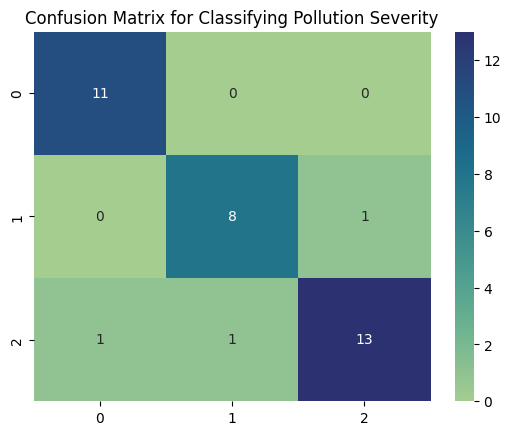

In [37]:
conf_matrix = confusion_matrix(y_test, predictions)
sns.heatmap(conf_matrix, annot=True, cmap='crest')
plt.title("Confusion Matrix for Classifying Pollution Severity")
plt.show()